In [1]:
import numpy as np
import gds_geometry_evaluator as gds

In [2]:
ft_for_IDCs = gds.FluxTrapSpec(
    trap_width_microns=4.0,
    horizontal_separation_microns=6.0,
    edge_margin_microns=4.0,
)

ft_for_GSs = gds.FluxTrapSpec(
    trap_width_microns=4.0,
    horizontal_separation_microns=6.0,
    edge_margin_microns=2.0,
)

ft_for_MIs = gds.FluxTrapSpec(
    trap_width_microns=4.0,
    horizontal_separation_microns=6.0,
    edge_margin_microns=2.0,
)

ft_for_GP = gds.FluxTrapSpec(
    trap_width_microns=20.0,
    horizontal_separation_microns=150.0,
    edge_margin_microns=10.0,
)

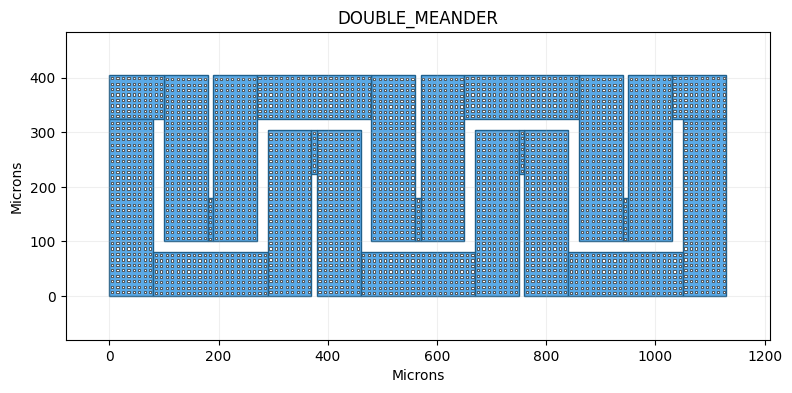

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'DOUBLE_MEANDER'}, xlabel='Microns', ylabel='Microns'>)

In [3]:
inductor_spec = gds.DoubleMeanderSpec(
    trace_width_microns=80.0,
    gap_width_microns=10.0,
    meander_inner_gap_width_microns=20.0,
    bounding_box_width_microns=1130.0,
    bounding_box_height_microns=404.0,
    flux_trap_spec=ft_for_MIs,
    layer=1,
)
inductor_built = gds.build_double_meander(inductor_spec)
inductor_built.plot()

# inductor_eval = gds.evaluate_generated_double_meander(inductor_spec, save_path=None, film_thickness_nanometers=30.0)
# print(inductor_eval)

In [4]:
finger_len_fracs = np.arange(1.0,0.0,-0.037)[:-1]
N_resonators = len(finger_len_fracs)
print(N_resonators, finger_len_fracs[0], finger_len_fracs[-1])

27 1.0 0.037999999999999146


In [5]:
idc_spec_list  = [None] * len(finger_len_fracs)
idc_built_list = [None] * len(finger_len_fracs)

for i, finger_len_f in enumerate(finger_len_fracs):

    idc_spec_list[i] = gds.IdcSpec(
        finger_count=15,
        finger_trace_width_microns=20.0,
        finger_length_microns=950.0,
        finger_gap_width_microns=20.0,
        arm_trace_width_microns=80.0,
        arm_gap_width_microns=10.0,
        bounding_box_width_microns=1130.0,
        final_finger_length_fraction=finger_len_f,
        include_bottom_bars=True,
        omit_top_arm_stubs=True,
        layer=2,
    )
    idc_built_list[i] = gds.build_idc(idc_spec_list[i])

In [6]:
idc_idx = -1
idc_built = idc_built_list[idc_idx]
idc_spec  = idc_spec_list[idc_idx]

# idc_built.plot()
# print(gds.evaluate_generated_idc(idc_spec, save_path=None, effective_permittivity=9.08))

In [7]:
gs_trace_width = 80.0
gs_gap_width = 20.0

ground_shield_spec = gds.GroundShieldSpec(
    trace_thickness_microns=gs_trace_width,
    horizontal_gap_microns=gs_gap_width,
    upper_gap_microns=gs_gap_width,
    lower_gap_microns=gs_gap_width,
    flux_trap_spec=None, #ft_for_GSs,
)

In [8]:
built_lekid_list = [None] * len(idc_spec_list)

for i, idc_spec in enumerate(idc_spec_list):
    built_lekid_list[i] = gds.build_double_meander_with_idc(
                            inductor_spec=inductor_spec,
                            idc_spec=idc_spec,
                            ground_shield_spec=ground_shield_spec,
                            idc_flux_trap_spec=ft_for_IDCs,
                            )

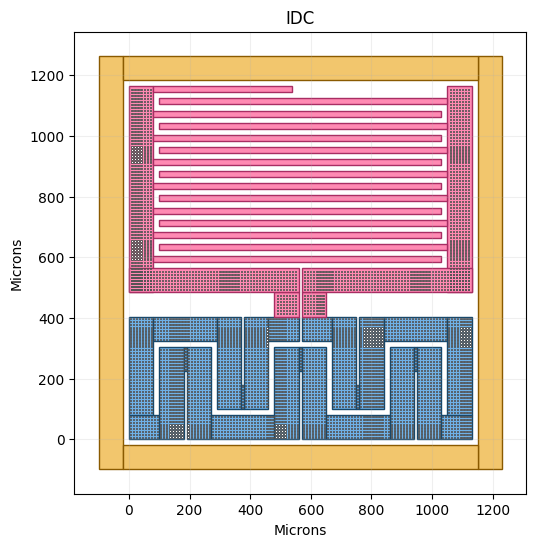

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'IDC'}, xlabel='Microns', ylabel='Microns'>)

In [9]:
lekid_idx = -13
built_lekid_list[lekid_idx].plot()

# print( gds.evaluate_generated_double_meander_with_idc(built_lekid_list[lekid_idx], 
#                                                effective_permittivity=9.08, 
#                                                kinetic_inductance_per_square_nh=0.0, 
#                                                film_thickness_nanometers=30.0
#                                               ) )

In [10]:
cpw_gap_width = 10.75
cpw_ground_width = 100.0

fl_launch_spec = gds.FeedlineLauncherSpec(
    central_conductor_width_microns=20,
    gap_width_microns=cpw_gap_width,
    ground_conductor_width_microns=cpw_ground_width,
    signal_bond_pad_edge_width_microns=300,
    ground_bond_pad_edge_width_microns=1500,
    template_path="/Users/dtemples/GDS-Geometry-Evaluator/assets/feedlines/feedline-launch-caltech-style.gds",
    layer=3,
    datatype=0,
)

fl_launch_built = gds.build_feedline_launcher(fl_launch_spec)
# fl_launch_built.plot()

In [11]:
fl_spec = gds.MeanderedFeedlineSpec(
    launcher_spec=fl_launch_spec,
    chip_width_microns=22000,
    chip_height_microns=22000,
    face="top",
    row_count=5,
    first_stub_length_microns=1500.0,
    final_stub_length_microns=1500.0,
    full_run_length_microns=18000.0,
    offset_microns=0,
    bend_style="slow-wave",
    slow_wave_bend_template_path="/Users/dtemples/GDS-Geometry-Evaluator/assets/feedlines/feedline-90-degree-bend-slowwave.gds",    
)

built_fl = gds.build_meandered_feedline(fl_spec)
# built_fl.plot()

In [12]:
horiz_position_micron = [
                                   2000.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -2000.0 
]

row_position = [         0,
                 1,1,1,1,1,
                 2,2,2,2,2,
                 3,3,3,3,3,
                 4,4,4,4,4,
                 5,5,5,5,5,
                 6,
]

orientation =  [         1,
                 -1,-1,-1,-1,-1,
                 1,1,1,1,1,
                 -1,-1,-1,-1,-1,
                 1,1,1,1,1,
                 -1,-1,-1,-1,-1,
                 1,
]

In [13]:
placed = gds.place_lekid_on_feedline(
        feedline_result=built_fl,
        lekid_result=built_lekid_list[0],
        spec=gds.LekidFeedlinePlacementSpec(
            separation_microns=orientation[0]*(cpw_gap_width+cpw_ground_width+gs_gap_width),
            position_microns=horiz_position_micron[0],
            row_index=row_position[0],
        )
    )

for i_kid in range(1,N_resonators):
    placed = gds.place_lekid_on_feedline(
        placed,
        lekid_result=built_lekid_list[i_kid],
        spec=gds.LekidFeedlinePlacementSpec(
            separation_microns=orientation[i_kid]*(cpw_gap_width+cpw_ground_width+gs_gap_width),
            position_microns=horiz_position_micron[i_kid],
            row_index=row_position[i_kid],
        ),
    )
    
# placed.plot()

In [ ]:
gds.write_built_gds("./MLA5G-Inductor-FingerTune-FullChip.gds", placed)